# 03. Targeting policy and profit

**Uplift Modeling and Targeting Policy** &nbsp;|&nbsp; Notebook 3 of 3

---

### What this notebook does

Turns the ranking from notebook 2 into a decision: who to advertise
to, how many of them, and whether it beats the alternatives.

Three rankings are compared against sending to everyone and against
random order, under two different billing contracts, across five
splits.

The central result is that the correct targeting rule depends on how
the advertiser is billed. Under a flat fee per targeted user, ranking
by uplift barely beats ranking by predicted response probability.
Under per-impression billing it becomes the worst of the three, and a
ranking that divides uplift by the chance of being shown an ad wins
by a wide margin.

### Carried in from notebooks 1 and 2

| Decision | Basis |
|---|---|
| Single model, raw scores, no calibration | Beat the two-model estimator in five of five paired seeds; calibration did not improve levels and increased variance |
| Primary outcome is `visit` | Notebook 1, sections 5 and 6 |
| Intent to treat on `treatment` as assigned | Notebook 1, section 2b |
| Only 3.6% of eligible users are ever shown an ad | Notebook 1, section 2b. The cost model depends on it |
| Noise floor on visit at 20 bins is 6.3% of the average effect | Notebook 1, section 6. Used again for the sleeping dogs test |

### Money, without inventing any

The dataset contains no economics. Costs are therefore expressed as a
single ratio:

```
r = cost of targeting one user / value of one visit
```

and profit is measured in visits, so no currency appears anywhere. A
reader who knows what a visit is worth to them multiplies the answer
by that number.

### Data

Criteo Uplift Prediction dataset, version 2.1. Not included in this
repository. See notebook 1 for the download link, file hash and
citation.

### Runtime

`DEV_MODE = True` runs on a 20% sample in a few minutes. A full run
is about 25 minutes for sections 1 to 10, plus 25 minutes for the
five-seed repeat in section 11.

## Setup

In [40]:
import time
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

In [41]:
DATA_PATH = Path("../Data/criteo-uplift-v2.1.csv.gz")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No file at {DATA_PATH.resolve()}. Check DATA_PATH."
    )

FEATURES = [f"f{i}" for i in range(12)]
TREATMENT_COL = "treatment"
OUTCOME = "visit"
BINARY_COLS = ["treatment", "visit", "conversion", "exposure"]

DTYPES = {name: "float32" for name in FEATURES}
DTYPES.update({name: "int8" for name in BINARY_COLS})

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

In [42]:
df = pd.read_csv(DATA_PATH, compression="gzip", dtype=DTYPES)
print(f"rows: {len(df):,}")

rows: 13,979,592


### Run configuration

In [43]:
TRAIN_SIZE = 0.60
VALID_SIZE = 0.20
SPLIT_SEED = 101

DEV_MODE = False
DEV_FRACTION = 0.20
DEV_SEED = 20260924

# Cost levels, expressed as a ratio. See the markdown below.
R_FLAT_LEVELS = [0.002, 0.005, 0.010]

# Exposure rate measured in step 1, used to match the two cost models
# to comparable total spend.
EXPOSURE_RATE = 0.036036
R_CPI_LEVELS = [round(r / EXPOSURE_RATE, 3) for r in R_FLAT_LEVELS]

# Guard against division by exactly zero. The observed minimum
# predicted exposure is 0.000275, so this never binds. A larger
# floor was tested and performed worse. See the sensitivity cell.
EXPOSURE_FLOOR = 1e-6

N_CURVE_POINTS = 201
N_DECILES = 10
N_NOISE_DRAWS = 50
NOISE_SEED = 555

LGB_PARAMS = {
    "objective": "binary",
    "n_estimators": 500,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 500,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "n_jobs": -1,
    "verbose": -1,
}
EARLY_STOPPING_ROUNDS = 50

trapezoid = getattr(np, "trapezoid", getattr(np, "trapz", None))

print("flat fee levels:", R_FLAT_LEVELS)
print("matched CPI levels:", R_CPI_LEVELS)

flat fee levels: [0.002, 0.005, 0.01]
matched CPI levels: [0.056, 0.139, 0.278]


## The cost parameter, r

### Why costs are a parameter and not a fact

Profit needs two numbers that this dataset does not contain: what a
visit is worth to the advertiser, and what it costs to target one
user. The features are anonymised and no economics are published, so
both would have to be invented.

Only their ratio matters. An advertiser with ten times the budget and
ten times the margin makes ten times the profit and targets exactly
the same people.

So costs are expressed as one ratio:

```
r = cost of targeting one user / value of one visit
```

Profit is then measured in visits, with no currency anywhere:

```
profit = incremental visits gained  -  r * users targeted
```

A reader who knows what a visit is worth to them multiplies the
answer by that number.

### Reading r

| r | Meaning |
|---|---|
| 0.002 | Targeting 500 users costs what one visit is worth |
| 0.005 | Targeting 200 users costs what one visit is worth |
| 0.010 | Targeting 100 users costs what one visit is worth |

The average uplift in this data is 0.0103 visits per targeted user,
so r = 0.010 is roughly the point where the average user breaks even.
The three levels chosen bracket that point, which is where the
decision is interesting. Far below it everyone is worth targeting;
far above it nobody is.

### The second cost model

If the advertiser is billed per ad actually shown, then a targeted
user only costs money when they come back and see something. Only
3.6% do.

```
profit = incremental visits gained  -  r * ads actually shown
```

Here r is the cost of one impression, in visit-equivalents. It is on
a different scale from the flat-fee r and the two cannot be compared
directly.

To make the two figures describe advertisers spending comparable
money, the CPI levels are set to the flat-fee levels divided by the
exposure rate.

## 1. Refit the models

Three models are needed.

In [44]:
def stratified_three_way_split(frame, outcome, seed,
                               train_size=TRAIN_SIZE,
                               valid_size=VALID_SIZE):
    """Split into train, validation and test, stratified.

    Strata are the combination of treatment arm and outcome, so all
    three parts keep the same arm ratio and event rate.

    Args:
        frame (pandas.DataFrame): Full dataset.
        outcome (str): Binary outcome column name.
        seed (int): Seed for the split.
        train_size (float): Share for training.
        valid_size (float): Share for validation.

    Returns:
        tuple: Three index arrays, for train, validation and test.
    """
    strata = (frame["treatment"].astype(str)
              + "_" + frame[outcome].astype(str))
    indices = np.arange(len(frame))

    train_index, holdout_index = train_test_split(
        indices, train_size=train_size, stratify=strata,
        random_state=seed)

    holdout_strata = strata.to_numpy()[holdout_index]
    valid_share = valid_size / (1 - train_size)

    valid_index, test_index = train_test_split(
        holdout_index, train_size=valid_share,
        stratify=holdout_strata, random_state=seed)

    return train_index, valid_index, test_index


def fit_model(features_train, labels_train, features_valid,
              labels_valid, params, seed):
    """Fit one LightGBM classifier with early stopping.

    Args:
        features_train (pandas.DataFrame): Training features.
        labels_train (numpy.ndarray): Training labels.
        features_valid (pandas.DataFrame): Validation features.
        labels_valid (numpy.ndarray): Validation labels.
        params (dict): LightGBM parameters.
        seed (int): Seed for the learner.

    Returns:
        lightgbm.LGBMClassifier: The fitted model.
    """
    model = lgb.LGBMClassifier(random_state=seed, **params)
    model.fit(
        features_train, labels_train,
        eval_set=[(features_valid, labels_valid)],
        eval_metric="binary_logloss",
        callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS,
                                      verbose=False)],
    )
    return model

In [45]:
if DEV_MODE:
    working = df.sample(frac=DEV_FRACTION, random_state=DEV_SEED)
    working = working.reset_index(drop=True)
else:
    working = df

train_index, valid_index, test_index = stratified_three_way_split(
    working, OUTCOME, SPLIT_SEED)

train = working.iloc[train_index]
valid = working.iloc[valid_index]
test = working.iloc[test_index]

print(f"working rows: {len(working):,}   dev mode: {DEV_MODE}")
print(f"test rows:    {len(test):,}")

working rows: 13,979,592   dev mode: False
test rows:    2,795,919


### Model 1. The uplift model

The single model from step 2. Trained on everyone with `treatment` as
a thirteenth input, then asked twice per user with that input forced
to 1 and to 0.

In [46]:
started = time.time()

uplift_columns = FEATURES + ["treatment"]

uplift_model = fit_model(
    train[uplift_columns], train[OUTCOME].to_numpy(),
    valid[uplift_columns], valid[OUTCOME].to_numpy(),
    LGB_PARAMS, SPLIT_SEED)


def predict_both_arms(model, frame, features):
    """Predict outcome probability under each treatment value.

    Args:
        model (lightgbm.LGBMClassifier): Fitted single model.
        frame (pandas.DataFrame): Rows to predict for.
        features (list): Feature column names.

    Returns:
        tuple: Probability if treated, probability if not.
    """
    columns = list(features) + ["treatment"]

    as_treated = frame[features].copy()
    as_treated["treatment"] = 1
    as_control = frame[features].copy()
    as_control["treatment"] = 0

    return (model.predict_proba(as_treated[columns])[:, 1],
            model.predict_proba(as_control[columns])[:, 1])


p_treated_test, p_control_test = predict_both_arms(
    uplift_model, test, FEATURES)

predicted_uplift = p_treated_test - p_control_test
predicted_response = p_treated_test

print(f"uplift model fitted in {time.time() - started:.0f}s")
print(f"mean predicted uplift: {predicted_uplift.mean():.6f}")

uplift model fitted in 272s
mean predicted uplift: 0.007293


### Model 2. The exposure model

This predicts the chance that a user, if made eligible, is actually
shown an ad.

Two things about it are worth being explicit about, because they
sound like they contradict earlier decisions.

It is trained on treated rows only. Control users have `exposure = 0`
by construction, since they were blocked from seeing ads. Including
them would teach the model that being in the control arm predicts no
exposure, which is true and useless.

It is a prediction, not a causal claim. Earlier steps ruled out using
`exposure` to define comparison groups, because exposure is caused by
user behaviour rather than assigned. That objection applies to causal
comparisons. Predicting who is likely to be reached is an ordinary
forecasting problem with no causal content, so it is legitimate.

For control users the model produces a counterfactual: the chance
they would have been shown an ad had they been made eligible.
Because assignment was random, the relationship learned on the
treated arm transfers.

In [47]:
started = time.time()

train_treated = train[train["treatment"] == 1]
valid_treated = valid[valid["treatment"] == 1]

exposure_model = fit_model(
    train_treated[FEATURES], train_treated["exposure"].to_numpy(),
    valid_treated[FEATURES], valid_treated["exposure"].to_numpy(),
    LGB_PARAMS, SPLIT_SEED)

predicted_exposure = exposure_model.predict_proba(
    test[FEATURES])[:, 1]

test_treated_mask = test["treatment"].to_numpy() == 1
exposure_auc = roc_auc_score(
    test.loc[test_treated_mask, "exposure"],
    predicted_exposure[test_treated_mask])

print(f"exposure model fitted in {time.time() - started:.0f}s")
print(f"observed exposure rate, treated test rows: "
      f"{test.loc[test_treated_mask, 'exposure'].mean():.6f}")
print(f"mean predicted exposure:                   "
      f"{predicted_exposure.mean():.6f}")
print(f"exposure model AUC on treated test rows:   {exposure_auc:.4f}")

exposure model fitted in 230s
observed exposure rate, treated test rows: 0.036070
mean predicted exposure:                   0.035163
exposure model AUC on treated test rows:   0.9222


The AUC here matters. If the model cannot predict exposure, the
exposure-adjusted ranking has nothing to work with and the whole CPI
comparison collapses to noise. An AUC near 0.5 would be a finding
that ends that half of the project. Anything comfortably above 0.7
means the ranking has real information behind it.

### Model 3, which is not a model

The third ranking is response probability: target the users most
likely to visit. This is the standard heuristic the project is
testing uplift against, and it needs no extra fitting because the
uplift model already produces it as `p(x, treatment=1)`.

## 2. The three rankings

### Dividing by exposure, and the floor that turned out to be unnecessary

Under CPI the correct ranking is uplift divided by the chance of
being shown an ad, because that is the effect per ad actually paid
for.

Division is dangerous when the denominator can approach zero. A user
with a 0.001% chance of exposure would have a near-zero predicted
uplift divided by a nearer-zero probability, producing noise
amplified into a large score.

This model does not produce such values. `min_child_samples` is 500,
so no leaf forms around a handful of unusual users, and the smallest
predicted exposure observed is 0.000275. The largest multiplier the
division can produce is therefore bounded at about 3,600.

A floor of 0.005 was tested and rejected. It sat above the median
predicted exposure, so it flattened more than half the audience, and
it performed worse on held-out data at every level tried. The
sensitivity cell below records that test.

The floor is kept at 1e-06 as a guard against division by exactly
zero. No user reaches it.

In [48]:
floored_exposure = np.maximum(predicted_exposure, EXPOSURE_FLOOR)
uplift_per_impression = predicted_uplift / floored_exposure

below_floor = (predicted_exposure < EXPOSURE_FLOOR)

print(f"exposure floor:              {EXPOSURE_FLOOR}")
print(f"users below the floor:       {below_floor.sum():,}"
      f"  ({below_floor.mean():.2%})")
print(f"their share of predicted uplift: "
      f"{predicted_uplift[below_floor].sum() / predicted_uplift.sum():.2%}")

rankings = {
    "Rank by uplift": predicted_uplift,
    "Rank by uplift / P(shown)": uplift_per_impression,
    "Rank by response probability": predicted_response,
    "Random order": np.random.default_rng(NOISE_SEED).random(len(test)),
}

exposure floor:              1e-06
users below the floor:       0  (0.00%)
their share of predicted uplift: 0.00%


### Where the predicted exposure probabilities sit

In [49]:
pd.Series(predicted_exposure).describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
)

count   2,795,919.000000
mean            0.035163
std             0.088639
min             0.000275
1%              0.000769
5%              0.000907
10%             0.001063
25%             0.001617
50%             0.003972
75%             0.019345
90%             0.095185
99%             0.479295
max             0.960695
dtype: float64

In [50]:
multiplier = 1.0 / np.maximum(predicted_exposure, EXPOSURE_FLOOR)

pd.Series({
    "exposure_floor": EXPOSURE_FLOOR,
    "min_predicted_exposure": predicted_exposure.min(),
    "users_below_floor": int((predicted_exposure
                              < EXPOSURE_FLOOR).sum()),
    "max_multiplier": multiplier.max(),
    "multiplier_p99": np.percentile(multiplier, 99),
})

exposure_floor               0.000001
min_predicted_exposure       0.000275
users_below_floor            0.000000
max_multiplier           3,635.921595
multiplier_p99           1,300.611313
dtype: float64

### The floor sensitivity test

Kept in the notebook as evidence the choice was tested rather than
assumed. Profit is measured on held-out test rows, so this is a
comparison and not an argument.

In [51]:
def floor_sensitivity(floors, r_grid):
    """Rerun the CPI comparison at several exposure floors.

    Args:
        floors (list): Floor values to test.
        r_grid (numpy.ndarray): Impression prices to scan.

    Returns:
        pandas.DataFrame: One row per floor.
    """
    rows = []
    for floor in floors:
        score = predicted_uplift / np.maximum(
            predicted_exposure, floor)
        curve = cumulative_curves(score, test, OUTCOME)

        crossover, _ = find_crossover(
            curves["Rank by uplift"], curve, profit_cpi, r_grid)

        middle_r = R_CPI_LEVELS[1]
        profit, fraction = best_profit(curve, profit_cpi, middle_r)

        rows.append({
            "floor": floor,
            "share_below_floor": float(
                (predicted_exposure < floor).mean()),
            "crossover_r": crossover,
            f"best_pool_at_r={middle_r}": fraction,
            f"profit_at_r={middle_r}": round(profit),
        })

    return pd.DataFrame(rows)

Run this cell after section 7, once `find_crossover`, `best_profit`
and `profit_cpi` exist.

```python
floor_sensitivity([0.0005, 0.001, 0.005, 0.020, 0.050],
                  np.linspace(0.01, 0.60, 60))
```

## 3. Cumulative curves

### What is being computed

Sort users by a ranking, best first. Walk down the list. At each
stopping point, record three things about everyone passed so far:

| Quantity | Meaning |
|---|---|
| `users` | How many people are in the pool |
| `gains` | Extra visits caused by targeting that pool |
| `impressions` | Ads actually shown to that pool |

### How gains is computed

Within the pool, compare the arms:

```
gains = pool size x (visit rate of treated in pool
                     - visit rate of control in pool)
```

The rate difference is the causal effect for people like these, and
multiplying by pool size scales it to what happens if the whole pool
is targeted.

### How impressions is computed

From observed data, not from the exposure model. Control users have
`exposure = 0` by construction, so the exposure rate is measured on
the treated users in the pool and scaled to the whole pool:

```
impressions = pool size x (exposure rate of treated in pool)
```

Using the model's predictions here would be circular, since one of
the rankings is built from those predictions.

In [52]:
def cumulative_curves(score, frame, outcome, n_points=N_CURVE_POINTS,
                      seed=0):
    """Cumulative users, incremental outcomes and impressions.

    Ties in the score are broken at random rather than by row order.

    Args:
        score (numpy.ndarray): Ranking score, higher is targeted first.
        frame (pandas.DataFrame): Test rows.
        outcome (str): Binary outcome column name.
        n_points (int): Points sampled along the curve.
        seed (int): Seed for tie breaking.

    Returns:
        pandas.DataFrame: Fraction, users, gains and impressions.
    """
    rng = np.random.default_rng(seed)
    tie_breaker = rng.permutation(len(score))
    order = np.lexsort((tie_breaker, -np.asarray(score)))

    treated = frame["treatment"].to_numpy()[order].astype(np.int64)
    response = frame[outcome].to_numpy()[order].astype(np.int64)
    exposed = frame["exposure"].to_numpy()[order].astype(np.int64)

    n_treated = np.cumsum(treated)
    n_control = np.cumsum(1 - treated)
    y_treated = np.cumsum(response * treated)
    y_control = np.cumsum(response * (1 - treated))
    e_treated = np.cumsum(exposed * treated)

    n_all = np.arange(1, len(order) + 1)

    safe_t = np.maximum(n_treated, 1)
    safe_c = np.maximum(n_control, 1)

    rate_treated = y_treated / safe_t
    rate_control = y_control / safe_c
    valid = (n_treated > 0) & (n_control > 0)

    gains = np.where(valid, n_all * (rate_treated - rate_control), 0.0)
    impressions = n_all * (e_treated / safe_t)

    positions = np.linspace(0, len(order), n_points).astype(int)
    positions[0] = 1

    return pd.DataFrame({
        "fraction": positions / len(order),
        "users": n_all[positions - 1],
        "gains": gains[positions - 1],
        "impressions": impressions[positions - 1],
    })


curves = {name: cumulative_curves(score, test, OUTCOME)
          for name, score in rankings.items()}

pd.DataFrame({
    name: curve.iloc[-1][["users", "gains", "impressions"]]
    for name, curve in curves.items()
}).T

,users,gains,impressions
Rank by uplift,"2,795,919.000000","28,916.909512","100,849.418130"
Rank by uplift / P(shown),"2,795,919.000000","28,916.909512","100,849.418130"
Rank by response probability,"2,795,919.000000","28,916.909512","100,849.418130"
Random order,"2,795,919.000000","28,916.909512","100,849.418130"


Every ranking should show identical values in that table. At 100% of
the audience the ordering no longer matters, so the totals must
agree. Differences beyond rounding mean the curve code is wrong.

## 4. Profit

Two functions, one per cost model.

In [53]:
def profit_flat(curve, r):
    """Profit in visit-equivalents under a flat fee per user.

    Args:
        curve (pandas.DataFrame): Output of cumulative_curves.
        r (float): Cost of targeting one user, in visits.

    Returns:
        numpy.ndarray: Profit at each point on the curve.
    """
    return curve["gains"].to_numpy() - r * curve["users"].to_numpy()


def profit_cpi(curve, r):
    """Profit in visit-equivalents under per-impression billing.

    Args:
        curve (pandas.DataFrame): Output of cumulative_curves.
        r (float): Cost of one impression, in visits.

    Returns:
        numpy.ndarray: Profit at each point on the curve.
    """
    return (curve["gains"].to_numpy()
            - r * curve["impressions"].to_numpy())

## 5. Figure A. Flat fee

Three panels, three cost levels.

What to watch: the peak slides left and sharpens as cost rises. The
order of the lines never changes.

That second point is not an accident. Under a flat fee every targeted
user costs the same, so the cost term is identical across rankings at
any given pool size. Comparing two rankings, it cancels. Cost decides
how many to target and never which ranking to use.

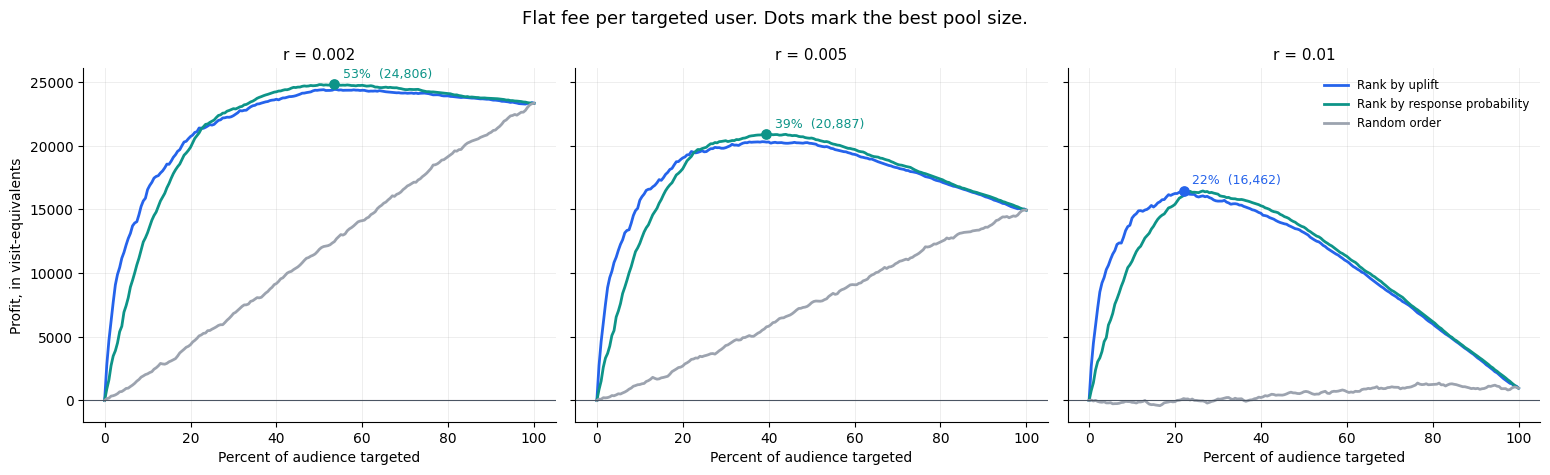

In [54]:
FLAT_SET = ["Rank by uplift", "Rank by response probability",
            "Random order"]
CPI_SET = ["Rank by uplift / P(shown)", "Rank by uplift",
           "Rank by response probability", "Random order"]

COLOURS = {
    "Rank by uplift": "#2563eb",
    "Rank by uplift / P(shown)": "#7c3aed",
    "Rank by response probability": "#0d9488",
    "Random order": "#9ca3af",
}


def plot_profit_panels(levels, profit_function, names, title,
                       cost_label):
    """Plot profit against pool size, one panel per cost level.

    Args:
        levels (list): Cost values, one per panel.
        profit_function (callable): profit_flat or profit_cpi.
        names (list): Ranking names to draw.
        title (str): Figure title.
        cost_label (str): How to describe r in each panel title.

    Returns:
        matplotlib.figure.Figure: The figure.
    """
    figure, axes = plt.subplots(
        1, len(levels), figsize=(5.2 * len(levels), 4.8), sharey=True)

    for axis, r in zip(np.atleast_1d(axes), levels):
        for name in names:
            values = profit_function(curves[name], r)
            axis.plot(curves[name]["fraction"] * 100, values,
                      label=name, color=COLOURS[name], lw=2)

        best_name = max(
            [n for n in names if n != "Random order"],
            key=lambda n: profit_function(curves[n], r).max(),
        )
        best_values = profit_function(curves[best_name], r)
        peak = int(np.argmax(best_values))
        peak_x = curves[best_name]["fraction"].to_numpy()[peak] * 100
        peak_y = best_values[peak]

        axis.scatter([peak_x], [peak_y], color=COLOURS[best_name],
                     s=45, zorder=5)
        axis.annotate(
            f"{peak_x:.0f}%  ({peak_y:,.0f})",
            (peak_x, peak_y),
            textcoords="offset points",
            xytext=(6, 5),
            fontsize=9,
            color=COLOURS[best_name],
        )

        axis.axhline(0, color="#4b5563", lw=0.8)
        axis.spines[["top", "right"]].set_visible(False)
        axis.grid(alpha=0.25, lw=0.6)
        axis.set_xlabel("Percent of audience targeted")
        axis.set_title(f"{cost_label} = {r}", fontsize=11)

    np.atleast_1d(axes)[0].set_ylabel("Profit, in visit-equivalents")
    np.atleast_1d(axes)[2].legend(fontsize=8.5, frameon=False,
                                  loc="upper right")
    figure.suptitle(title, fontsize=13)
    figure.tight_layout()
    return figure


figure_a = plot_profit_panels(
    R_FLAT_LEVELS, profit_flat, FLAT_SET,
    "Flat fee per targeted user. Dots mark the best pool size.",
    "r")
plt.show()

## 6. Figure B. Per impression

The same three advertisers, billed differently. The cost levels are
the flat-fee levels divided by the 3.6% exposure rate, so each panel
here describes roughly the same total spend as the matching panel
above.

What to watch: the purple line, which ranks by uplift divided by the
chance of being shown an ad. At low cost it loses. At high cost it
wins. Somewhere between, the lines swap.

Why cost changes the answer here and not under a flat fee: different
rankings target users with different exposure probabilities, so they
run up different bills for the same pool size. The cost term no
longer cancels when comparing rankings.

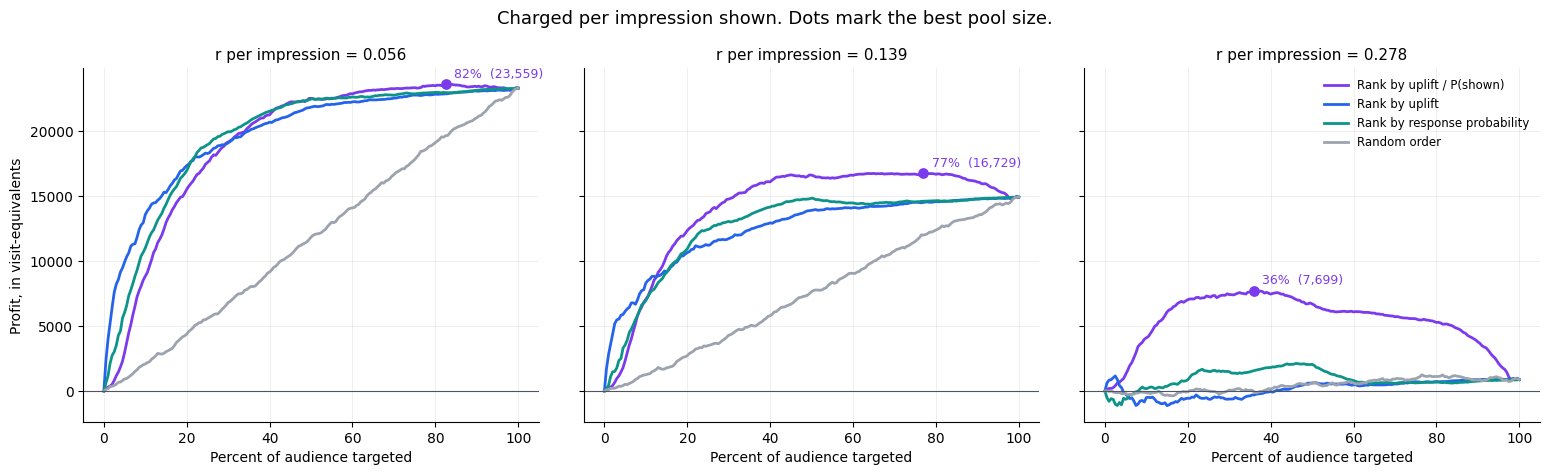

In [55]:
figure_b = plot_profit_panels(
    R_CPI_LEVELS, profit_cpi, CPI_SET,
    "Charged per impression shown. Dots mark the best pool size.",
    "r per impression")
plt.show()

## 7. The crossover

The single most quotable number in the project: the impression price
above which the exposure-adjusted ranking becomes the better rule.

It is found by comparing each ranking at its own best pool size,
across a fine grid of prices, and locating where the winner changes.

In [56]:
def best_profit(curve, profit_function, r):
    """Best achievable profit and the pool size that achieves it.

    Args:
        curve (pandas.DataFrame): Output of cumulative_curves.
        profit_function (callable): profit_flat or profit_cpi.
        r (float): Cost level.

    Returns:
        tuple: Best profit and the fraction targeted.
    """
    values = profit_function(curve, r)
    peak = int(np.argmax(values))
    return values[peak], float(curve["fraction"][peak])


def find_crossover(curve_a, curve_b, profit_function, r_grid):
    """Find where curve_b overtakes curve_a at its own optimum.

    Args:
        curve_a (pandas.DataFrame): Baseline ranking curve.
        curve_b (pandas.DataFrame): Challenger ranking curve.
        profit_function (callable): profit_flat or profit_cpi.
        r_grid (numpy.ndarray): Cost values to scan.

    Returns:
        tuple: Crossover cost or None, and a table of the scan.
    """
    rows = []
    crossover = None
    previous = None

    for r in r_grid:
        profit_a, frac_a = best_profit(curve_a, profit_function, r)
        profit_b, frac_b = best_profit(curve_b, profit_function, r)
        b_wins = profit_b > profit_a

        if previous is not None and b_wins and not previous:
            crossover = r
        previous = b_wins

        rows.append({
            "r": r,
            "uplift_profit": profit_a,
            "uplift_best_fraction": frac_a,
            "adjusted_profit": profit_b,
            "adjusted_best_fraction": frac_b,
            "adjusted_wins": b_wins,
        })

    return crossover, pd.DataFrame(rows)


r_scan = np.linspace(0.01, 0.60, 60)

crossover_r, scan = find_crossover(
    curves["Rank by uplift"],
    curves["Rank by uplift / P(shown)"],
    profit_cpi, r_scan)

if crossover_r is None:
    print("No crossover within the scanned range.")
else:
    print(f"Exposure-adjusted ranking overtakes at "
          f"r = {crossover_r:.3f} per impression")
    print(f"In flat-fee terms that is roughly "
          f"{crossover_r * EXPOSURE_RATE:.5f} per targeted user")

scan.iloc[::6]

Exposure-adjusted ranking overtakes at r = 0.050 per impression
In flat-fee terms that is roughly 0.00180 per targeted user


,r,uplift_profit,uplift_best_fraction,adjusted_profit,adjusted_best_fraction,adjusted_wins
0,0.010000,"27,935.316562",0.995000,"27,913.689328",0.995000,False
6,0.070000,"21,903.357524",0.995000,"22,398.551888",0.825000,True
12,0.130000,"15,871.398487",0.995000,"17,454.893801",0.770000,True
18,0.190000,"9,839.439449",0.995000,"13,180.944545",0.415000,True
24,0.250000,"3,807.480411",0.995000,"9,352.592861",0.415000,True
30,0.310000,390.303342,0.010000,"5,848.616084",0.220000,True
36,0.370000,-0.370000,0.000000,"3,573.868663",0.185000,True
42,0.430000,-0.430000,0.000000,"1,443.961837",0.180000,True
48,0.490000,-0.490000,0.000000,97.899689,0.010000,True
54,0.550000,-0.550000,0.000000,68.765862,0.010000,True


## 8. Table 1. Flat fee

Pool sizes down the rows, cost levels across the columns. The
break-even column is the highest price at which that pool still makes
money, which works out as the average uplift of the users in it.

In [57]:
POOL_SIZES = [0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]


def policy_table(curve, profit_function, levels, pool_sizes,
                 cost_basis):
    """Profit by pool size and cost level, with break-even prices.

    Args:
        curve (pandas.DataFrame): Output of cumulative_curves.
        profit_function (callable): profit_flat or profit_cpi.
        levels (list): Cost values for the columns.
        pool_sizes (list): Fractions for the rows.
        cost_basis (str): "users" or "impressions".

    Returns:
        pandas.DataFrame: One row per pool size.
    """
    rows = []
    for fraction in pool_sizes:
        position = int(np.argmin(
            np.abs(curve["fraction"].to_numpy() - fraction)))
        gains = curve["gains"].iloc[position]
        basis = curve[cost_basis].iloc[position]

        row = {
            "pool": f"top {int(fraction * 100)}%",
            "users": int(curve["users"].iloc[position]),
            "incremental_visits": round(gains),
            "impressions": round(curve["impressions"].iloc[position]),
            "break_even_r": gains / basis if basis > 0 else np.nan,
        }
        for r in levels:
            row[f"r={r}"] = round(gains - r * basis)
        rows.append(row)

    return pd.DataFrame(rows)


flat_table = policy_table(
    curves["Rank by uplift"], profit_flat, R_FLAT_LEVELS,
    POOL_SIZES, "users")

flat_table

,pool,users,incremental_visits,impressions,break_even_r,r=0.002,r=0.005,r=0.01
0,top 5%,139795,12475,45715,0.089237,12195,11776,11077
1,top 10%,279591,17107,63329,0.061185,16547,15709,14311
2,top 20%,559183,21832,80509,0.039042,20713,19036,16240
3,top 30%,838775,24031,88648,0.028650,22354,19837,15643
4,top 50%,1397959,27161,95494,0.019429,24365,20172,13182
5,top 75%,2096939,28294,99207,0.013493,24100,17809,7324
6,top 100%,2795919,28917,100849,0.010343,23325,14937,958


In [58]:
for r in R_FLAT_LEVELS:
    column = f"r={r}"
    best = flat_table.loc[flat_table[column].idxmax()]
    print(f"r={r}: target {best['pool']}, "
          f"profit {best[column]:,.0f} visit-equivalents")

r=0.002: target top 50%, profit 24,365 visit-equivalents
r=0.005: target top 50%, profit 20,172 visit-equivalents
r=0.01: target top 20%, profit 16,240 visit-equivalents


### Strategy against strategy, at full curve resolution

The table above uses seven fixed pool sizes. This uses the full 201
point curve, so each strategy is compared at its own best pool size
rather than at a shared set of cutoffs.

This is the comparison the project set out to make: does ranking by
predicted uplift beat ranking by predicted response probability.

In [59]:
rows = []
for r in R_FLAT_LEVELS:
    blanket = profit_flat(curves["Rank by uplift"], r)[-1]
    for name in FLAT_SET:
        profit, fraction = best_profit(curves[name], profit_flat, r)
        rows.append({
            "r": r,
            "strategy": name,
            "best_pool": fraction,
            "profit": round(profit),
            "vs_blanket": round(profit - blanket),
        })
    rows.append({
        "r": r,
        "strategy": "Send to everyone",
        "best_pool": 1.0,
        "profit": round(blanket),
        "vs_blanket": 0,
    })

pd.DataFrame(rows)

,r,strategy,best_pool,profit,vs_blanket
0,0.002000,Rank by uplift,0.535000,24412,1087
1,0.002000,Rank by response probability,0.535000,24806,1481
2,0.002000,Random order,1.000000,23325,0
3,0.002000,Send to everyone,1.000000,23325,0
4,0.005000,Rank by uplift,0.385000,20308,5370
5,0.005000,Rank by response probability,0.395000,20887,5949
6,0.005000,Random order,0.995000,14944,6
7,0.005000,Send to everyone,1.000000,14937,0
8,0.010000,Rank by uplift,0.220000,16462,15504
9,0.010000,Rank by response probability,0.265000,16441,15483


## 9. Table 2. Per impression

Same structure, with cost driven by impressions rather than users,
and one extra question answered: which ranking wins at each price.

In [60]:
cpi_table = policy_table(
    curves["Rank by uplift / P(shown)"], profit_cpi, R_CPI_LEVELS,
    POOL_SIZES, "impressions")

cpi_table

,pool,users,incremental_visits,impressions,break_even_r,r=0.056,r=0.139,r=0.278
0,top 5%,139795,3386,7619,0.444437,2960,2327,1268
1,top 10%,279591,10007,21277,0.470335,8816,7050,4092
2,top 20%,559183,17640,38204,0.461730,15500,12329,7019
3,top 30%,838775,22084,52771,0.418482,19129,14749,7413
4,top 50%,1397959,26471,71123,0.372193,22489,16585,6699
5,top 75%,2096939,27785,79966,0.347463,23307,16670,5555
6,top 100%,2795919,28917,100849,0.286734,23269,14899,881


In [61]:
rows = []
for r in R_CPI_LEVELS:
    uplift_profit, uplift_fraction = best_profit(
        curves["Rank by uplift"], profit_cpi, r)
    adjusted_profit, adjusted_fraction = best_profit(
        curves["Rank by uplift / P(shown)"], profit_cpi, r)
    rows.append({
        "r_per_impression": r,
        "uplift_best_pool": uplift_fraction,
        "uplift_profit": round(uplift_profit),
        "adjusted_best_pool": adjusted_fraction,
        "adjusted_profit": round(adjusted_profit),
        "winner": ("uplift / P(shown)"
                   if adjusted_profit > uplift_profit else "uplift"),
    })

pd.DataFrame(rows)

,r_per_impression,uplift_best_pool,uplift_profit,adjusted_best_pool,adjusted_profit,winner
0,0.056000,0.995000,23311,0.825000,23559,uplift / P(shown)
1,0.139000,0.995000,14967,0.770000,16729,uplift / P(shown)
2,0.278000,0.025000,1162,0.360000,7699,uplift / P(shown)


## 10. Sleeping dogs

### The question

Some users may visit less often because they were advertised to.
Annoyance, irrelevance, whatever the reason. If they exist and can be
identified, excluding them is free profit.

### Why it is hard to answer

Uplift for any group is a difference between two small rates, and
step 1 measured how much apparent difference this dataset produces
from nothing at all. At 20 bins that noise floor is 0.065 percentage
points, which is 6.3% of the average effect.

So a decile showing negative uplift is only evidence if the negative
value is larger than what random grouping produces.

### The test

Split the test set into ten groups by predicted uplift. For each,
compute the observed uplift with a confidence interval. Then do the
same thing with users assigned to groups at random, fifty times, and
take the range those random groups occupy.

A decile counts as a sleeping dog group only if its observed uplift
sits below the random band.

In [62]:
def decile_uplift(score, frame, outcome, n_bins=N_DECILES, seed=0):
    """Observed uplift within bins of a ranking score.

    Args:
        score (numpy.ndarray): Ranking score.
        frame (pandas.DataFrame): Test rows.
        outcome (str): Binary outcome column name.
        n_bins (int): Number of equal-count bins.
        seed (int): Seed for tie breaking.

    Returns:
        pandas.DataFrame: One row per bin.
    """
    rng = np.random.default_rng(seed)
    tie_breaker = rng.permutation(len(score))
    order = np.lexsort((tie_breaker, -np.asarray(score)))

    treated = frame["treatment"].to_numpy()[order]
    response = frame[outcome].to_numpy()[order]

    bins = np.minimum(
        (np.arange(len(order)) * n_bins) // len(order), n_bins - 1)

    rows = []
    for index in range(n_bins):
        mask = bins == index
        arm_t = response[mask & (treated == 1)]
        arm_c = response[mask & (treated == 0)]

        rate_t, rate_c = arm_t.mean(), arm_c.mean()
        std_err = np.sqrt(
            rate_t * (1 - rate_t) / len(arm_t)
            + rate_c * (1 - rate_c) / len(arm_c))

        rows.append({
            "decile": index + 1,
            "n_treated": len(arm_t),
            "n_control": len(arm_c),
            "rate_treated": rate_t,
            "rate_control": rate_c,
            "uplift": rate_t - rate_c,
            "ci_lower": rate_t - rate_c - 1.96 * std_err,
            "ci_upper": rate_t - rate_c + 1.96 * std_err,
        })

    return pd.DataFrame(rows)


observed_deciles = decile_uplift(
    predicted_uplift, test, OUTCOME)

observed_deciles

,decile,n_treated,n_control,rate_treated,rate_control,uplift,ci_lower,ci_upper
0,1,242339,37253,0.289380,0.228196,0.061183,0.056555,0.065812
1,2,237543,42049,0.107050,0.099741,0.007309,0.004187,0.010432
2,3,237102,42490,0.037802,0.036950,0.000852,-0.001099,0.002803
3,4,236656,42936,0.011379,0.010318,0.001062,0.000015,0.002109
4,5,236800,42792,0.005532,0.004160,0.001372,0.000693,0.002052
5,6,237286,42306,0.003102,0.002529,0.000573,0.000044,0.001101
6,7,237420,42172,0.001777,0.001328,0.000450,0.000063,0.000836
7,8,237063,42529,0.001333,0.001199,0.000134,-0.000226,0.000494
8,9,237266,42326,0.001100,0.000780,0.000320,0.000023,0.000618
9,10,237056,42535,0.021543,0.020877,0.000667,-0.000813,0.002146


In [63]:
def random_decile_band(frame, outcome, n_bins=N_DECILES,
                       n_draws=N_NOISE_DRAWS, seed=NOISE_SEED):
    """Range of decile uplifts produced by random grouping.

    Args:
        frame (pandas.DataFrame): Test rows.
        outcome (str): Binary outcome column name.
        n_bins (int): Number of bins.
        n_draws (int): Number of random groupings.
        seed (int): Seed for the draw sequence.

    Returns:
        pandas.Series: Summary of the null spread.
    """
    rng = np.random.default_rng(seed)
    treated = frame["treatment"].to_numpy()
    response = frame[outcome].to_numpy()

    values = []
    for draw in range(n_draws):
        bins = rng.integers(0, n_bins, size=len(frame))
        cell = bins * 2 + treated
        positives = np.bincount(cell, weights=response,
                                minlength=n_bins * 2).reshape(n_bins, 2)
        counts = np.bincount(cell,
                             minlength=n_bins * 2).reshape(n_bins, 2)
        values.append(positives[:, 1] / counts[:, 1]
                      - positives[:, 0] / counts[:, 0])

    values = np.concatenate(values)
    return pd.Series({
        "null_mean": values.mean(),
        "null_sd": values.std(ddof=1),
        "null_p2.5": np.percentile(values, 2.5),
        "null_p97.5": np.percentile(values, 97.5),
        "null_min": values.min(),
    })


null_band = random_decile_band(test, OUTCOME)
null_band

null_mean    0.010343
null_sd      0.000963
null_p2.5    0.008363
null_p97.5   0.012277
null_min     0.007502
dtype: float64

### What the random band does and does not test

The band is built from randomly grouped users. Random groups all have
the same true uplift, equal to the overall average of 0.010343, so the
band is centred on the average rather than on zero.

That makes it the wrong test for harm. A decile falling below the band
is below average, which is what any working uplift model produces, and
says nothing about whether those users were pushed away.

It is the right test for heterogeneity. If the observed spread across
deciles is much wider than the band, the model is separating users
beyond anything random grouping produces.

So the two columns below answer two different questions, and only one
of them decides the sleeping dog verdict.

| Column | Question |
|---|---|
| `below_average_beyond_noise` | Is this decile detectably below average |
| `ci_excludes_zero_negative` | Is this decile's uplift detectably negative |

Only the second can identify a sleeping dog group.

In [64]:
verdict = observed_deciles[["decile", "uplift", "ci_lower",
                            "ci_upper"]].copy()
verdict["below_average_beyond_noise"] = (
    verdict["uplift"] < null_band["null_p2.5"])
verdict["ci_excludes_zero_negative"] = verdict["ci_upper"] < 0
verdict["sleeping_dog"] = verdict["ci_excludes_zero_negative"]

verdict

,decile,uplift,ci_lower,ci_upper,below_average_beyond_noise,ci_excludes_zero_negative,sleeping_dog
0,1,0.061183,0.056555,0.065812,False,False,False
1,2,0.007309,0.004187,0.010432,True,False,False
2,3,0.000852,-0.001099,0.002803,True,False,False
3,4,0.001062,0.000015,0.002109,True,False,False
4,5,0.001372,0.000693,0.002052,True,False,False
5,6,0.000573,0.000044,0.001101,True,False,False
6,7,0.000450,0.000063,0.000836,True,False,False
7,8,0.000134,-0.000226,0.000494,True,False,False
8,9,0.000320,0.000023,0.000618,True,False,False
9,10,0.000667,-0.000813,0.002146,True,False,False


In [65]:
spread = observed_deciles["uplift"].max() - observed_deciles["uplift"].min()
band_width = null_band["null_p97.5"] - null_band["null_p2.5"]

pd.Series({
    "decile_1_uplift": observed_deciles["uplift"].iloc[0],
    "decile_10_uplift": observed_deciles["uplift"].iloc[-1],
    "observed_spread": spread,
    "null_band_width": band_width,
    "spread_over_band": spread / band_width,
})

decile_1_uplift     0.061183
decile_10_uplift    0.000667
observed_spread     0.061050
null_band_width     0.003914
spread_over_band   15.599657
dtype: float64

### How to read the verdict

A decile counts as a sleeping dog group only if its confidence
interval sits entirely below zero.

If none qualifies, the honest conclusion is that no detectable group
was pushed away at this sample size. That is a result, and it gets
reported rather than replaced with a weaker claim.

The heterogeneity figures above are a separate finding. A spread many
times the width of the null band is evidence the model is genuinely
separating users, which matters if the headline comparison between
rankings comes out close.

In [66]:
excluded = verdict.loc[verdict["sleeping_dog"], "decile"].tolist()

if not excluded:
    print("No decile qualifies as a sleeping dog group.")
else:
    print(f"Sleeping dog deciles: {excluded}")
    rng = np.random.default_rng(0)
    tie_breaker = rng.permutation(len(predicted_uplift))
    order = np.lexsort((tie_breaker, -predicted_uplift))
    bins = np.minimum(
        (np.arange(len(order)) * N_DECILES) // len(order),
        N_DECILES - 1)

    keep_mask = np.ones(len(order), dtype=bool)
    for decile in excluded:
        keep_mask[bins == decile - 1] = False

    inverse = np.empty(len(order), dtype=int)
    inverse[order] = np.arange(len(order))
    keep = keep_mask[inverse]

    trimmed = cumulative_curves(
        np.where(keep, predicted_uplift, -np.inf), test, OUTCOME)

    for r in R_FLAT_LEVELS:
        full_profit, _ = best_profit(
            curves["Rank by uplift"], profit_flat, r)
        trimmed_profit, _ = best_profit(trimmed, profit_flat, r)
        print(f"r={r}: {full_profit:,.0f} -> {trimmed_profit:,.0f}")

No decile qualifies as a sleeping dog group.


## 11. Repeating across five split seeds

### Why this is needed

Everything above rests on one split. The split is random, so every
number carries sampling variation on top of everything else.

Step 2 measured that variation on Qini: about 2% from seed to seed.
Applied to a profit figure around 20,000 visit-equivalents, that is a
few hundred.

The headline comparison between uplift ranking and response ranking
turned on margins of 394 and 579. Those margins are the same size as
the noise already measured, so a single split cannot settle which
ranking wins.

A negative result needs its error bars more than a positive one does.

### What this runs

The whole pipeline, five times: split, fit the uplift model, fit the
exposure model, build all curves, record the best profit for every
strategy at every cost level.

Cost is roughly four minutes per seed on the full data, so about
twenty minutes.

### What to look at

The paired difference between response ranking and uplift ranking,
seed by seed. Paired, because both are evaluated on the same test set
within a seed, so the split's own luck cancels.

- Same sign in all five seeds, the difference is real.
- Sign flips between seeds, the two rankings are indistinguishable
  and the write-up should say so.

In [67]:
def run_full_seed(frame, seed):
    """Refit both models on one split and score every strategy.

    Args:
        frame (pandas.DataFrame): Working dataset.
        seed (int): Seed for the split and the learners.

    Returns:
        tuple: A results frame and a diagnostics dictionary.
    """
    started = time.time()

    train_i, valid_i, test_i = stratified_three_way_split(
        frame, OUTCOME, seed)
    train_s = frame.iloc[train_i]
    valid_s = frame.iloc[valid_i]
    test_s = frame.iloc[test_i]

    columns = FEATURES + ["treatment"]
    seed_uplift_model = fit_model(
        train_s[columns], train_s[OUTCOME].to_numpy(),
        valid_s[columns], valid_s[OUTCOME].to_numpy(),
        LGB_PARAMS, seed)

    p_treated, p_control = predict_both_arms(
        seed_uplift_model, test_s, FEATURES)
    seed_uplift = p_treated - p_control

    train_treated_s = train_s[train_s["treatment"] == 1]
    valid_treated_s = valid_s[valid_s["treatment"] == 1]
    seed_exposure_model = fit_model(
        train_treated_s[FEATURES],
        train_treated_s["exposure"].to_numpy(),
        valid_treated_s[FEATURES],
        valid_treated_s["exposure"].to_numpy(),
        LGB_PARAMS, seed)

    seed_exposure = seed_exposure_model.predict_proba(
        test_s[FEATURES])[:, 1]

    treated_mask = test_s["treatment"].to_numpy() == 1

    seed_rankings = {
        "Rank by uplift": seed_uplift,
        "Rank by uplift / P(shown)": seed_uplift / np.maximum(
            seed_exposure, EXPOSURE_FLOOR),
        "Rank by response probability": p_treated,
    }
    seed_curves = {name: cumulative_curves(score, test_s, OUTCOME)
                   for name, score in seed_rankings.items()}

    rows = []
    blanket_flat = None
    for r in R_FLAT_LEVELS:
        blanket_flat = profit_flat(
            seed_curves["Rank by uplift"], r)[-1]
        for name in ["Rank by uplift",
                     "Rank by response probability"]:
            profit, fraction = best_profit(
                seed_curves[name], profit_flat, r)
            rows.append({
                "seed": seed, "cost_model": "flat", "r": r,
                "strategy": name, "best_pool": fraction,
                "profit": profit, "blanket": blanket_flat,
            })

    for r in R_CPI_LEVELS:
        blanket_cpi = profit_cpi(
            seed_curves["Rank by uplift"], r)[-1]
        for name in ["Rank by uplift",
                     "Rank by uplift / P(shown)",
                     "Rank by response probability"]:
            profit, fraction = best_profit(
                seed_curves[name], profit_cpi, r)
            rows.append({
                "seed": seed, "cost_model": "cpi", "r": r,
                "strategy": name, "best_pool": fraction,
                "profit": profit, "blanket": blanket_cpi,
            })

    crossover, _ = find_crossover(
        seed_curves["Rank by uplift"],
        seed_curves["Rank by uplift / P(shown)"],
        profit_cpi, np.linspace(0.01, 0.60, 60))

    diagnostics = {
        "seed": seed,
        "exposure_auc": roc_auc_score(
            test_s.loc[treated_mask, "exposure"],
            seed_exposure[treated_mask]),
        "mean_predicted_uplift": seed_uplift.mean(),
        "crossover_r": crossover,
        "seconds": time.time() - started,
    }

    return pd.DataFrame(rows), diagnostics

In [68]:
SEED_LIST = [101, 102, 103, 104, 105]

seed_frames = []
seed_diagnostics = []

for seed in SEED_LIST:
    frame_out, diagnostic = run_full_seed(working, seed)
    seed_frames.append(frame_out)
    seed_diagnostics.append(diagnostic)
    print(f"seed {seed} done in {diagnostic['seconds']:.0f}s, "
          f"crossover {diagnostic['crossover_r']}")

seed_results = pd.concat(seed_frames, ignore_index=True)
pd.DataFrame(seed_diagnostics)

seed 101 done in 538s, crossover 0.05
seed 102 done in 651s, crossover None
seed 103 done in 455s, crossover None
seed 104 done in 564s, crossover 0.02
seed 105 done in 581s, crossover 0.02


,seed,exposure_auc,mean_predicted_uplift,crossover_r,seconds
0,101,0.922163,0.007293,0.050000,537.807081
1,102,0.921897,0.007400,NaN,651.241861
2,103,0.921930,0.007289,NaN,455.387938
3,104,0.921606,0.007325,0.020000,564.084038
4,105,0.921991,0.007282,0.020000,581.037484


### Profit by strategy, across seeds

In [69]:
seed_results.groupby(
    ["cost_model", "r", "strategy"]
).agg(
    profit_mean=("profit", "mean"),
    profit_sd=("profit", "std"),
    profit_min=("profit", "min"),
    profit_max=("profit", "max"),
    pool_mean=("best_pool", "mean"),
).reset_index()

,cost_model,r,strategy,profit_mean,profit_sd,profit_min,profit_max,pool_mean
0,cpi,0.056000,Rank by response probability,"23,295.610591",45.380930,"23,269.210332","23,375.620032",0.941000
1,cpi,0.056000,Rank by uplift,"23,410.214810",166.756991,"23,261.831508","23,672.863419",0.990000
2,cpi,0.056000,Rank by uplift / P(shown),"23,761.481347",171.687989,"23,559.408934","23,950.311253",0.874000
3,cpi,0.139000,Rank by response probability,"14,942.405269",60.682279,"14,898.513334","15,041.942093",0.940000
4,cpi,0.139000,Rank by uplift,"15,087.997350",201.180749,"14,880.198038","15,395.224084",0.963000
5,cpi,0.139000,Rank by uplift / P(shown),"16,827.966205",274.479527,"16,600.860038","17,299.911126",0.679000
6,cpi,0.278000,Rank by response probability,"2,125.732313",88.840347,"2,018.677725","2,264.953771",0.475000
7,cpi,0.278000,Rank by uplift,"1,418.160955",164.418709,"1,161.786631","1,584.808633",0.418000
8,cpi,0.278000,Rank by uplift / P(shown),"8,065.214439",317.829326,"7,698.998773","8,418.909575",0.340000
9,flat,0.002000,Rank by response probability,"24,923.564650",124.519686,"24,776.309640","25,047.572046",0.547000


### The paired test that settles the headline

Response ranking minus uplift ranking, within each seed. Positive
means response ranking won that seed.

In [70]:
flat = seed_results[seed_results["cost_model"] == "flat"]
wide = flat.pivot_table(
    index=["r", "seed"], columns="strategy", values="profit")

wide["response_minus_uplift"] = (
    wide["Rank by response probability"] - wide["Rank by uplift"])

paired = wide.reset_index()[
    ["r", "seed", "Rank by uplift",
     "Rank by response probability", "response_minus_uplift"]]

paired

strategy,r,seed,Rank by uplift,Rank by response probability,response_minus_uplift
0,0.002000,101,"24,411.892155","24,806.332403",394.440248
1,0.002000,102,"24,930.779565","24,776.309640",-154.469925
2,0.002000,103,"25,090.883552","24,967.842670",-123.040882
3,0.002000,104,"24,835.815199","25,047.572046",211.756848
4,0.002000,105,"25,022.051326","25,019.766488",-2.284838
5,0.005000,101,"20,307.503715","20,886.558670",579.054954
6,0.005000,102,"20,696.075093","20,850.638479",154.563386
7,0.005000,103,"20,928.294365","20,752.746524",-175.547841
8,0.005000,104,"20,816.981171","20,966.936033",149.954862
9,0.005000,105,"21,292.097176","21,151.731719",-140.365457


In [71]:
summary = paired.groupby("r")["response_minus_uplift"].agg(
    mean="mean",
    sd="std",
    min="min",
    max="max",
    seeds_response_wins=lambda values: int((values > 0).sum()),
    n_seeds="size",
).reset_index()

summary

,r,mean,sd,min,max,seeds_response_wins,n_seeds
0,0.002000,65.280290,233.517519,-154.469925,394.440248,2,5
1,0.005000,113.531981,303.213165,-175.547841,579.054954,3,5
2,0.010000,-241.681557,222.485985,-552.821493,-20.542290,0,5


Read `seeds_response_wins` against `n_seeds`.

- 5 of 5 or 0 of 5, the difference is consistent and can be stated.
- Anything in between, the two rankings are indistinguishable at this
  sample size, and that is what the write-up should say.

Compare `sd` against `mean`. If the standard deviation across seeds
is the same size as the mean difference, the margin is inside the
noise regardless of how the signs fell.

### The per-impression comparison, across seeds

In [72]:
cpi = seed_results[seed_results["cost_model"] == "cpi"]
cpi_wide = cpi.pivot_table(
    index=["r", "seed"], columns="strategy", values="profit")

cpi_wide["adjusted_minus_uplift"] = (
    cpi_wide["Rank by uplift / P(shown)"]
    - cpi_wide["Rank by uplift"])

cpi_wide.reset_index().groupby("r")[
    "adjusted_minus_uplift"].agg(
    mean="mean", sd="std", min="min", max="max",
    seeds_adjusted_wins=lambda values: int((values > 0).sum()),
).reset_index()

,r,mean,sd,min,max,seeds_adjusted_wins
0,0.056000,351.266538,114.095672,248.594301,475.979031,5
1,0.139000,"1,739.968855",320.947714,"1,302.257453","2,132.562551",5
2,0.278000,"6,647.053484",264.036241,"6,319.522060","6,949.457706",5


## 12. Decisions to record after this step

One line each, from the output above.

1. Exposure model AUC, and whether the CPI comparison has real
   information behind it.
2. Best pool size and profit at each flat-fee cost level.
3. Whether uplift ranking beats response ranking under a flat fee,
   and by how much.
4. The crossover price at which the exposure-adjusted ranking
   overtakes, and what that means in plain terms.
5. Whether any sleeping dog group survived the noise band, and the
   profit consequence if so.
6. How many users sit below the exposure floor, and how sensitive the
   CPI result is to that choice.